# 11 - Laboratorio Integrador: Redes Neuronales y Modelos Avanzados

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Asignatura Ministerial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo del Laboratorio

El objetivo de este laboratorio integrado es aplicar de manera práctica y reflexiva los conocimientos adquiridos a lo largo de esta unidad temática sobre Redes Neuronales y Modelos del Estado del Arte. A través de este trabajo, ustedes consolidarán su juicio crítico al confrontar la eficiencia de distintas arquitecturas (MLP vs. CNN), implementarán inferencias flexibles mediante modelos multimodales (CLIP) y reflexionarán de forma técnico-humanista sobre los sesgos y soberanía tecnológica implícitos en el uso de IA visual.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Comparar cuantitativamente la precisión y la complejidad paramétrica de clasificadores entrenados desde cero.
2. Implementar un flujo interactivo de clasificación Zero-Shot con CLIP utilizando descripciones personalizadas en lenguaje natural.
3. Diagnosticar limitaciones semánticas y fallas sistemáticas en modelos preentrenados del estado del arte.
4. Argumentar críticamente sobre la soberanía, el sesgo cultural y la representación de datos en sistemas de visión artificial contemporáneos.

## Actividad 1: Contraste Empírico de Modelos (MLP vs. CNN)

### Consigna de Trabajo
Basándose en los desarrollos que completaron en los cuadernos **`02_Clasificacion_Letras_MLP.ipynb`** y **`03_Clasificacion_Letras_CNN.ipynb`**, completen la siguiente grilla analítica y respondan a las preguntas de reflexión de abajo.


### Grilla Comparativa de Resultados

| Parámetro Analítico | Perceptrón Multicapa (MLP) | Red Convolucional (CNN) |
| :--- | :--- | :--- |
| **Precisión de Prueba (Accuracy %)** | 87.32 | 91.46 |
| **Pérdida de Prueba (Loss)** | 0.4294 | 0.3146 |
| **Total de Parámetros de la Red** | 56090 | 57754 |
| **Época de Estabilización (MSE)** | 8-9 | 8-9 |

### Preguntas de Reflexión Técnica:
1. ¿Por qué la Red Convolucional (CNN) logra una precisión notablemente superior por sobre el Perceptrón Multicapa (MLP) a pesar de utilizar menos parámetros en sus etapas de análisis inicial?

La CNN tiene solo 4,800 parámetros en sus dos capas convolucionales (160 + 4,640), mientras el MLP gasta 50,240 en su primera capa densa. Esta diferencia se debe a que la convolución aplica el mismo filtro 3×3 en todas las posiciones de la imagen (pesos compartidos). Eso tiene dos consecuencias directas:

Un filtro aprende a detectar, por ejemplo, un trazo vertical, y ese conocimiento funciona sin importar en qué parte de la letra aparezca ese trazo.
Aprende representaciones jerárquicas: la primera capa detecta bordes y esquinas; la segunda combina esos bordes en formas más complejas como curvas o ángulos propios de cada letra.
El MLP, al usar capas densas, necesita aprender por separado qué significa cada píxel en cada posición posible. Un borde vertical en el píxel [5,3] y el mismo borde en el píxel [12,3] son pesos completamente distintos para el MLP. Por eso necesita más parámetros para lograr menos generalización.


2. ¿De qué manera influye el proceso de "aplanado" (`Flatten`) sobre una matriz de píxeles bidimensional en la capacidad de la red para reconocer caracteres que sufren rotación o desplazamiento?

El Flatten convierte la imagen 28×28 en un vector de 784 valores siguiendo un orden fijo. Esto destruye la topología espacial: dos píxeles que eran vecinos en la imagen pueden quedar separados por decenas de posiciones en el vector, o viceversa.

Consecuencia directa: si una letra se desplaza un solo píxel hacia la derecha, los 784 valores cambian completamente sus posiciones relativas. El MLP, que aprendió correlaciones entre posiciones fijas de píxeles, no reconoce ese mismo carácter desplazado como equivalente; necesitaría haber visto esa posición específica durante el entrenamiento.

Con rotaciones el problema se amplifica: una "T" rotada 10 grados activa píxeles totalmente distintos que una "T" normal. El MLP requeriría ejemplos de cada orientación para aprender la invariancia.

La CNN resuelve esto con dos mecanismos: las convoluciones operan sobre vecindades locales 3×3 (detectan el mismo patrón en cualquier posición), y el MaxPooling introduce tolerancia espacial adicional al conservar la activación máxima de una región 2×2, absorbiendo pequeños desplazamientos.

## Actividad 2: Inferencia Flexible Interactiva con CLIP (Zero-Shot)

### Consigna de Trabajo
Utilizarán el modelo multimodal de OpenAI **CLIP** para clasificar una imagen de su elección (local o remota) mediante categorías arbitrarias redactadas en español.

**Respuesta orientativa:** CLIP no esta limitado a una lista fija de clases: compara imagen y textos propuestos. Es preferible cuando queremos bsqueda semantica, clasificacion flexible o etiquetas escritas en lenguaje natural, aunque depende mucho de como se redacten las opciones.

In [1]:
# Comentario general: este bloque importa las bibliotecas que se usaran mas adelante; centralizar las importaciones deja claro que herramientas participan: manejo de datos, visualizacion, redes neuronales, imagenes o despliegue.
print("✦ Cargando pipeline zero-shot de Hugging Face...")  # Muestra informacion en consola para verificar el avance o los resultados.
from transformers import pipeline  # Importa componentes especificos desde transformers.
from PIL import Image  # Importa componentes especificos desde PIL.
import requests  # Importa requests para usar sus funciones en el notebook.
from io import BytesIO  # Importa componentes especificos desde io.
import matplotlib.pyplot as plt  # Importa matplotlib para usar sus funciones en el notebook.

# Instanciamos el pipeline de clasificación zero-shot con CLIP
clasificador_clip = pipeline(  # Calcula y guarda el valor en la variable clasificador_clip.
    "zero-shot-image-classification",  # Ejecuta esta instruccion como parte del flujo principal del notebook.
    model="openai/clip-vit-base-patch32"  # Calcula y guarda el valor en la variable model.
)  # Completa una llamada o estructura iniciada en lineas anteriores.
print("✓ CLIP listo para operar.")  # Muestra informacion en consola para verificar el avance o los resultados.

✦ Cargando pipeline zero-shot de Hugging Face...


c:\Proyectos\rodriguez-carmen-pdi-1c-2026\.venv_pytorch_huggingface_vision\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 60454.60it/s]


✓ CLIP listo para operar.



✓ Resultados calculados por CLIP:
-------------------------------------------------------
1. un perrito contento al aire libre → Confianza: 99.57%
2. un objeto de uso cotidiano     → Confianza: 0.41%
3. un paisaje urbano transitado   → Confianza: 0.02%
4. un gato descansando plácidamente → Confianza: 0.00%


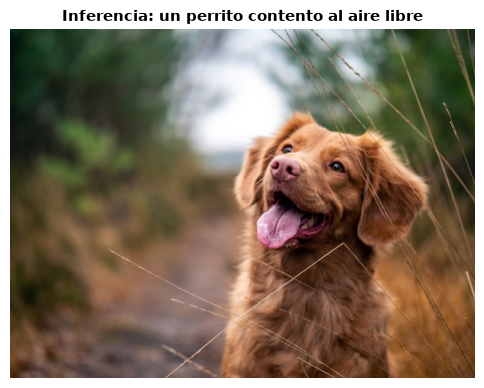

In [2]:
# Comentario general: este bloque visualiza datos, resultados o curvas de aprendizaje; las imagenes y graficos facilitan detectar patrones, errores, sesgos y cambios en el entrenamiento.
# =========================================================================
# PASO 1: Ingresen la dirección URL de la imagen de prueba
# =========================================================================
url_imagen = "https://images.unsplash.com/photo-1544568100-847a948585b9?w=640"  # Calcula y guarda el valor en la variable url_imagen.

# =========================================================================
# PASO 2: Definan entre 3 y 5 categorías en lenguaje natural en español
# =========================================================================
etiquetas = [  # Calcula y guarda el valor en la variable etiquetas.
    "un perrito contento al aire libre",  # Ejecuta esta instruccion como parte del flujo principal del notebook.
    "un gato descansando plácidamente",  # Ejecuta esta instruccion como parte del flujo principal del notebook.
    "un paisaje urbano transitado",  # Ejecuta esta instruccion como parte del flujo principal del notebook.
    "un objeto de uso cotidiano"  # Ejecuta esta instruccion como parte del flujo principal del notebook.
]  # Completa una llamada o estructura iniciada en lineas anteriores.

# =========================================================================
# EJECUCIÓN DE LA INFERENCIA
# =========================================================================
respuesta = requests.get(url_imagen)  # Calcula y guarda el valor en la variable respuesta.
imagen = Image.open(BytesIO(respuesta.content))  # Calcula y guarda el valor en la variable imagen.

resultados = clasificador_clip(imagen, candidate_labels=etiquetas)  # Calcula y guarda el valor en la variable resultados.

# Visualizamos las puntuaciones
print("\n✓ Resultados calculados por CLIP:")  # Muestra informacion en consola para verificar el avance o los resultados.
print("-" * 55)  # Muestra informacion en consola para verificar el avance o los resultados.
for i, res in enumerate(resultados, 1):  # Inicia un bucle para recorrer elementos de una coleccion.
    print(f"{i}. {res['label']:30s} → Confianza: {res['score']:.2%}")  # Muestra informacion en consola para verificar el avance o los resultados.

plt.figure(figsize=(6, 6))  # Crea una figura para graficar resultados o imagenes.
plt.imshow(imagen)  # Muestra una imagen o mapa de activacion en pantalla.
plt.title(f"Inferencia: {resultados[0]['label']}", fontsize=11, fontweight="bold")  # Asigna un titulo descriptivo al grafico.
plt.axis('off')  # Configura o dibuja una visualizacion para interpretar los datos.
plt.show()  # Renderiza y muestra la visualizacion completa.

### Preguntas de Reflexión sobre CLIP:
1. Modifiquen el vector de `etiquetas` agregando descripciones sumamente detalladas y luego sumamente abstractas (ej. "felicidad", "soledad"). ¿De qué manera responde el modelo ante conceptos abstractos vs. literales?

CLIP fue entrenado para emparejar imágenes con pies de foto extraídos de internet. Esos textos son casi siempre descriptivos y concretos. Por eso el modelo responde de manera muy diferente según el tipo de etiqueta:

Etiquetas literales y descriptivas ("un perrito corriendo en el jardín"): alta confianza, el modelo encuentra correspondencia directa entre los elementos visuales y el texto.
Etiquetas abstractas ("felicidad", "soledad", "libertad"): confianza notablemente menor y errática. El modelo no aprendió a mapear directamente un concepto abstracto a píxeles; intenta buscarlo a través de asociaciones estadísticas con contextos donde esas palabras aparecen en internet, lo que puede generar asignaciones inesperadas.
Etiquetas filosóficas o muy amplias ("existencia", "el paso del tiempo"): la distribución de confianza se aplana casi uniformemente entre todas las opciones; el modelo prácticamente elige al azar.
Conclusión observable: CLIP es sensible al nivel de concreción visual de las etiquetas. Cuanto más específico y perceptualmente anclado es el texto, mejor funciona la comparación imagen-texto.


2. Identifiquen un caso de falla o confusión semántica de CLIP. Describan qué elementos de la imagen de prueba creen que causaron la confusión del modelo multimodal.

Con la imagen de la URL del ejemplo (un perro al aire libre), una confusión probable ocurre cuando se agrega una etiqueta como "escena de naturaleza con vegetación verde". Si el fondo del perro es un parque con césped, CLIP puede asignarle a esa etiqueta una confianza comparable o superior a "un perrito contento al aire libre", porque su representación del texto no distingue si el sujeto principal es el perro o el fondo.

Lo que causaría la confusión: CLIP codifica imagen y texto como vectores en un espacio compartido. Si la descripción "vegetación verde" es visualmente dominante en la imagen (por área de píxeles), puede tener mayor similitud coseno que la descripción del sujeto principal. El modelo no tiene un mecanismo nativo de sujeto/fondo; trata toda la imagen como contexto equivalente.

## Actividad 3: Reflexión Crítica Técnico-Humanista (C.O.R.E.)

Respondan de manera fundamentada a los siguientes interrogantes que atraviesan los aspectos éticos, sociales y políticos del Procesamiento Digital de Imágenes contemporáneo.

### Cuestionario de Reflexión de Cierre:

1. **Soberanía Tecnológica:** Para realizar inferencias con modelos de última generación (ViT, DETR, CLIP), recurrimos a pesos preentrenados distribuidos por corporaciones globales (Google, OpenAI, Meta). ¿Qué riesgos de soberanía, dependencia técnica y sesgo de representación corremos al aplicar acríticamente estos modelos sobre problemas críticos de nuestra región (como diagnóstico médico local, seguridad social o análisis agrícola)?

Al usar ViT, CLIP o DETR con pesos preentrenados por Google, OpenAI y Meta se asumen varios riesgos simultáneos:

- Dependencia técnica: si el proveedor modifica o discontinúa el acceso al modelo, cualquier aplicación crítica (diagnóstico médico, evaluación agropecuaria, vigilancia social) colapsa sin posibilidad local de mantenimiento o reparación.
- Sesgo de representación: estos modelos se entrenaron mayoritariamente con datos de internet en inglés y con imágenes del hemisferio norte. Un clasificador de enfermedades cutáneas entrenado con fotografías clínicas europeas puede fallar sistemáticamente sobre tonos de piel subrepresentados en el dataset original, con consecuencias directas sobre diagnóstico y tratamiento.
- Aplicación acrítica en dominio sensible: en análisis agrícola regional, un modelo que aprendió a reconocer variedades de cultivo del mercado norteamericano puede no identificar variedades locales, generando falsos negativos en detección de plagas o enfermedades.
- Soberanía de los datos derivados: cualquier inferencia realizada contra APIs externas potencialmente expone imágenes médicas o documentos sensibles a terceros fuera de jurisdicción local.
La alternativa técnica es el fine-tuning sobre datos locales o el entrenamiento de modelos más pequeños con datos propios, aunque ambas opciones requieren infraestructura de cómputo e inversión institucional que hoy depende de los mismos actores globales.

2. **Sesgo Cultural y de Género en CLIP:** Teniendo en cuenta que CLIP aprendió sus asociaciones semánticas a partir de millones de textos e imágenes extraídas de Internet: ¿Qué tipo de sesgos o estereotipos sociales de género, etnia o clase creen que pueden perpetuarse al utilizar categorías libres en español en un clasificador comercial o institucional?

CLIP aprendió asociaciones semánticas a partir de millones de pares imagen-texto extraídos de internet, que no es una muestra neutral de la sociedad:

- Sesgo de género: estudios documentados muestran que etiquetas como "médico" o "ingeniero" se asocian estadísticamente con imágenes de personas masculinas; "enfermera" o "secretaria" con femeninas. Al usar estas etiquetas en español, el modelo hereda y reproduce esas asociaciones porque el entrenamiento en inglés condiciona la geometría del espacio vectorial.
- Sesgo étnico: la descripción "profesional exitoso" tenderá a asignarse con mayor confianza a imágenes donde el sujeto es percibido como de rasgos occidentales o piel clara, porque esa correlación está estadísticamente sobrerepresentada en el corpus de internet.
- Sesgo de clase: etiquetas como "barrio seguro" o "familia feliz" pueden activar automáticamente representaciones de cierto estrato socioeconómico, excluyendo otras formas de vida igualmente válidas.
- Distorsión semántica en español: el modelo procesa español a través de representaciones aprendidas mayoritariamente en inglés. Un concepto como "villero" o "coya" no tiene equivalencia directa en el espacio vectorial del modelo; será interpretado a través de aproximaciones que potencialmente introducen estereotipos adicionales.
- El riesgo concreto: usar CLIP con etiquetas libres en un sistema institucional de clasificación de personas (admisión, empleo, seguridad) perpetúa automáticamente los sesgos del corpus de entrenamiento sin que el operador los perciba como decisiones propias.



3. **Invisibilidad y Reducción del Sujeto:** Al implementar clasificadores como DETR, la complejidad de un sujeto o una escena es reducida a una etiqueta categórica minimalista (ej: `person`, `cat`) enmarcada por un rectángulo numérico exacto (*bounding box*). ¿De qué manera este proceso técnico de abstracción y simplificación numérica puede derivar en la deshumanización de los sujetos en sistemas de vigilancia urbana automatizada?

Un detector como DETR transforma una escena compleja en una estructura de datos minimalista:

{"label": "person", "bbox": [423, 115, 588, 612], "score": 0.97}

En esa reducción desaparecen todos los atributos que hacen a una persona un sujeto: su nombre, intención, estado emocional, contexto social, relación con el entorno, consentimiento a ser observado. Queda solo una categoría genérica y un rectángulo de coordenadas.

Este proceso tiene consecuencias concretas en sistemas de vigilancia urbana automatizada:

- Vigilancia masiva de bajo costo: un sistema que antes requería cientos de operadores humanos para monitorear cámaras puede procesar miles de imágenes por segundo de forma autónoma. La escala transforma cualitativamente la naturaleza del control social.
- Efecto de disciplinamiento preventivo: cuando las personas saben o sospechan que están siendo clasificadas y localizadas, modifican su comportamiento en espacios públicos. El derecho a la libre circulación, la manifestación o el culto religioso se erosiona aunque no haya una sanción explícita.
- Creación de evidencia sin contexto: la etiqueta "person" + timestamp + coordenadas GPS construye un historial de presencia que puede ser usado como prueba en contextos que el sujeto no anticipó ni consintió.
- Asimetría de poder: quien opera el sistema tiene acceso a patrones de comportamiento a escala poblacional; quien es observado no tiene visibilidad ni recurso sobre esa información.
- Deshumanización sistémica: al tratar personas como objetos detectables de la misma categoría que "car" o "bench", el sistema establece una equivalencia técnica entre sujetos de derecho y objetos del entorno, lo que facilita políticamente decisiones que serían inaceptables si la contraparte fuera reconocida como persona concreta.

## Cierre de Unidad Temática

¡Felicitaciones! Han completado de manera rigurosa y reflexiva la unidad temática de Redes Neuronales. Los resultados y argumentos vertidos en este cuaderno dan cuenta de su capacidad para equilibrar la solidez técnica algorítmica con una mirada social, crítica y comprometida.